In [1]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.shape

(768, 9)

In [3]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

for c in cols:
    df[c] = df.groupby('Outcome')[c].transform(lambda x: x.fillna(x.median()))

In [4]:
df[cols].isnull().sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8636363636363636
Confusion Matrix:
[[91  9]
 [12 42]]
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       100
           1       0.82      0.78      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.84      0.85       154
weighted avg       0.86      0.86      0.86       154



In [10]:
import pandas as pd
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Insulin                     0.358680
Glucose                     0.166993
SkinThickness               0.142720
BMI                         0.086094
Age                         0.077464
DiabetesPedigreeFunction    0.071659
BloodPressure               0.049346
Pregnancies                 0.047044
dtype: float64


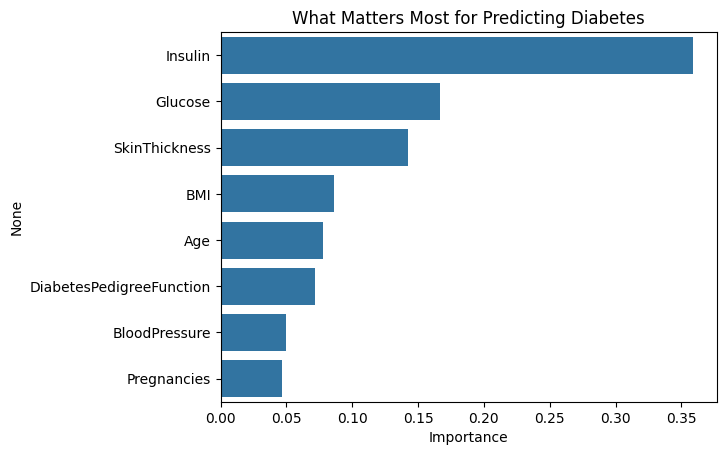

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=importances.values, y=importances.index)
plt.title('What Matters Most for Predicting Diabetes')
plt.xlabel('Importance')
plt.show()

In [12]:
sample = pd.DataFrame([[4, 165, 78, 32, 145, 34.2, 0.55, 46]], columns=X.columns)
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)[0]

print('Prediction:', 'Diabetic' if prediction == 1 else 'Not Diabetic')

Prediction: Diabetic
